# **CDS Project: Part 2**

*Institute of Software Security (E22)*  
*Hamburg University of Technology*  
*SoSe 2023*

## Learning objectives
---

- Identify and extract vulnerable code from software reposiroties
- Identify and extract non-vulnerabile code from software reposiroties.
- Select and apply pre-proceesing techniques.
- Create a dataset of security vulnerabilities.

## Materials
---

- Lecture Slides 3, 5 and 6.
- PyTorch Documentation: [Datasets and Data Loaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) 
- [ProjectKB GitHub repo](https://github.com/SAP/project-kb).
- PyDriller Documentation: [PyDriller](https://pydriller.readthedocs.io/en/latest/)

## Project Description
---

In this project, you will create your own dataset of security vulnerabilities. This dataset shoul be generated using the information contained in ProjectKB. ProjectKB is a repository created to enable the creation, management and aggregation of a distributed and collaborative knowledge base of vulnerabilities affecting open-source software written in Java programming language. This repository contains a list of CVEs and the corresponding commits that fix it. Usually the vulnerabilities are contained in a method. Your task is to use this repository to extract the vulnerable and fixed version of the methods.

###*Task 1*

- Download the ProjectKB repository (i.e., create a local copy by cloning it).
- Locate the folder containing the CVEs and their corresponding fixing commits.

###*Task 2*

- Write a script that extracts (i) the repository URLs and (ii) corresponding fixing commit ID (hash) contained on each CVE.

In [15]:
# TODO: From ProjectKB extract the commit IDs of the fixing commits 

# TODO: Extract the URLs of the respositories that contain the fix for different CVEs 

import os
import yaml

statements_path = "/home/huso/Desktop/Cybersecurity Data Science/Lab 2/project-kb/statements"
results = []

for cve in os.listdir(statements_path):
    yaml_file = os.path.join(statements_path, cve, "statement.yaml")
    if not os.path.isfile(yaml_file):
        continue

    with open(yaml_file, "r") as f:
        data = yaml.safe_load(f)

    for fix in data.get("fixes", []):
        for commit in fix.get("commits", []):
            repo_url  = commit.get("repository")
            commit_id = commit.get("id")
            if repo_url and commit_id:
                results.append({
                    "cve":              data.get("vulnerability_id", cve),
                    "repository_url":   repo_url,
                    "fixing_commit_id": commit_id,
                })

print(f"Total {len(results)} records.")
for r in results[:5]:
    print(r)

Total 1885 records.
{'cve': 'CVE-2015-2913', 'repository_url': 'https://github.com/orientechnologies/orientdb.git', 'fixing_commit_id': '668ece96be210e742a4e2820a3085b215cf55104'}
{'cve': 'CVE-2015-0838', 'repository_url': 'https://github.com/dulwich/dulwich', 'fixing_commit_id': 'b25e8390074060ea2aed25cf070b8e98b85a3875'}
{'cve': 'CVE-2017-7561', 'repository_url': 'https://github.com/resteasy/Resteasy', 'fixing_commit_id': '517db971d8f7094124416bf72091fd0b45a1302'}
{'cve': 'CVE-2017-7561', 'repository_url': 'https://github.com/resteasy/Resteasy', 'fixing_commit_id': 'e9a34f2513e75dcaba95e1f2bc6f21668f43985'}
{'cve': 'CVE-2017-7561', 'repository_url': 'https://github.com/resteasy/Resteasy', 'fixing_commit_id': 'fd66aad3cb1e8553323a9af5b58f1ad5150dc5b'}


In [ ]:
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

clone_dir = "/home/huso/Desktop/Cybersecurity Data Science/Lab 2/repos"
progress_file = "/home/huso/Desktop/Cybersecurity Data Science/Lab 2/cloned_repos.txt"

os.makedirs(clone_dir, exist_ok=True)

# load already cloned repos to avoid cloning them again
if os.path.exists(progress_file):
    with open(progress_file, "r") as f:
        already_cloned = set(f.read().splitlines())
else:
    already_cloned = set()

# get unique repo URLs from results, skip already cloned ones
repo_urls = list(set(r["repository_url"] for r in results) - already_cloned)
print(f"{len(repo_urls)} repos left to clone.")

def clone_repo(url):
    repo_name = url.rstrip("/").split("/")[-1].replace(".git", "")
    local_path = os.path.join(clone_dir, repo_name)

    if os.path.exists(local_path):
        return url, "already exists"

    try:
        subprocess.run(
            ["git", "clone", "--quiet", url, local_path],
            check=True, timeout=600
        )
        # save to progress file so we don't clone it again next time
        with open(progress_file, "a") as f:
            f.write(url + "\n")
        return url, "ok"
    except Exception as e:
        return url, f"ERROR: {e}"

# clone repos in parallel with 5 workers
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = {executor.submit(clone_repo, url): url for url in repo_urls}
    for i, future in enumerate(as_completed(futures)):
        url, status = future.result()
        repo_name = url.rstrip("/").split("/")[-1].replace(".git", "")
        print(f"[{i+1}/{len(repo_urls)}] {repo_name}: {status}")

###*Task 3*

- Using the URL, identify and extract the method where the "fix" is introduced. 
- Locate the previous version of the file and extract the same function (i.e., the "vulnerable" version of the same function). 

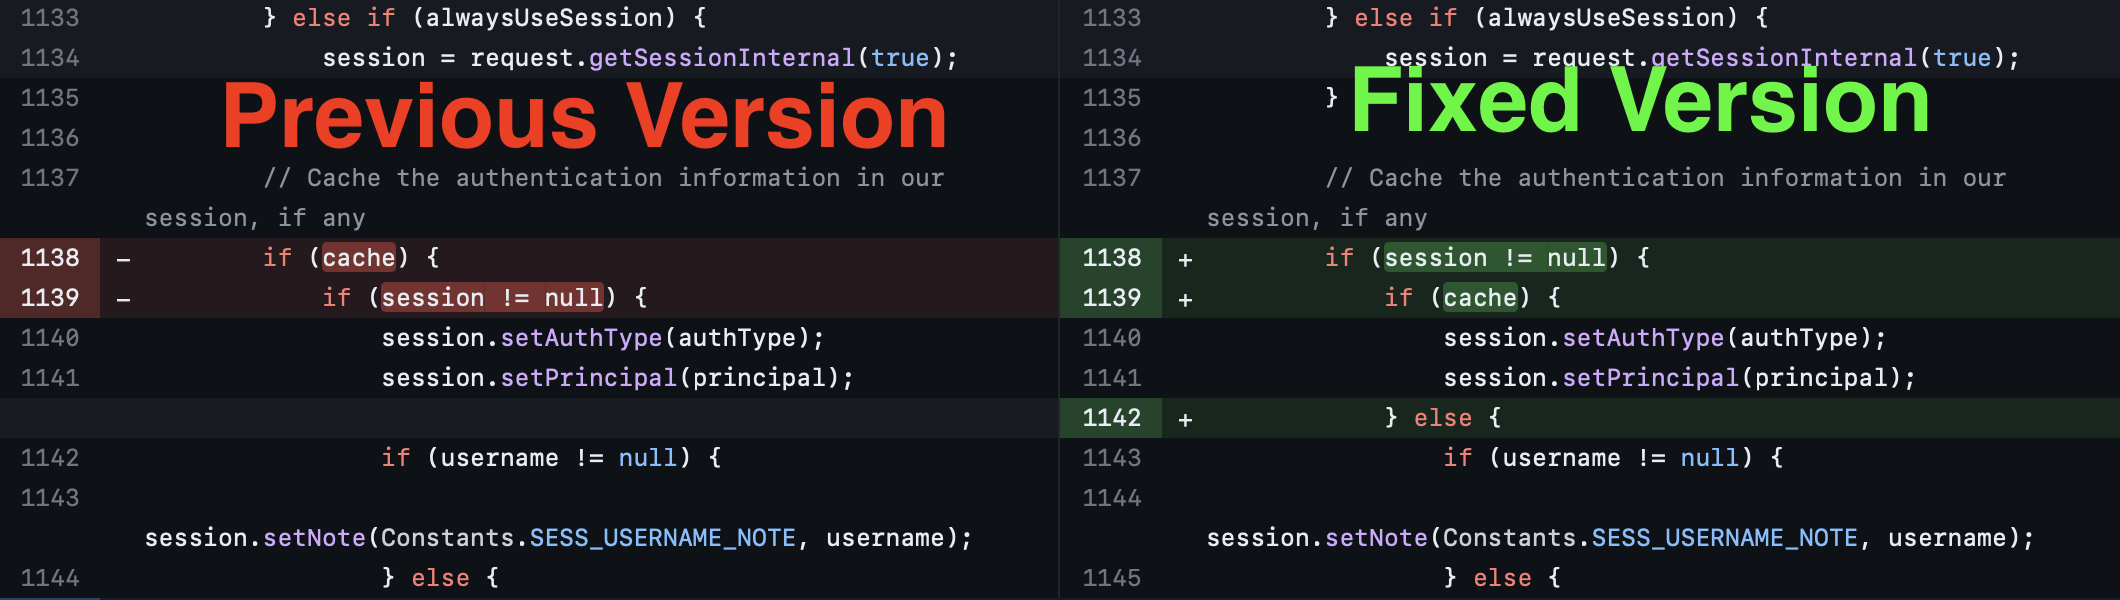

In [ ]:
# TODO: Extract the method where the fix is introduced
# TODO: Extract the vulnerable version of the same method from the previous version of the file.

from pydriller import Repository

processed_file = "/home/huso/Desktop/Cybersecurity Data Science/Lab 2/processed_commits.txt"

# load already processed commits to avoid processing them again
if os.path.exists(processed_file):
    with open(processed_file, "r") as f:
        processed = set(f.read().splitlines())
else:
    processed = set()

# extract the method code between given line numbers
def extract_method_by_lines(source_code, start_line, end_line):
    if not source_code:
        return None
    lines = source_code.splitlines()
    return "\n".join(lines[start_line - 1 : end_line])

# find lines that actually changed (ignore whitespace-only changes)
def get_changed_line_numbers(diff_parsed):
    added_lines   = {ln: l.strip() for ln, l in diff_parsed.get("added", [])}
    deleted_lines = {ln: l.strip() for ln, l in diff_parsed.get("deleted", [])}
    added_contents   = set(added_lines.values())
    deleted_contents = set(deleted_lines.values())
    changed = set()
    for ln, content in added_lines.items():
        if content not in deleted_contents:
            changed.add(ln)
    for ln, content in deleted_lines.items():
        if content not in added_contents:
            changed.add(ln)
    return changed

# check if a method contains any of the changed lines
def method_overlaps_changes(method, changed_lines):
    return any(method.start_line <= ln <= method.end_line for ln in changed_lines)

dataset = []

for i, entry in enumerate(results):
    cve       = entry["cve"]
    repo_url  = entry["repository_url"]
    commit_id = entry["fixing_commit_id"]

    # skip if already processed
    if commit_id in processed:
        print(f"[{i+1}/{len(results)}] Skipping (already processed): {commit_id[:8]}")
        continue

    repo_name  = repo_url.rstrip("/").split("/")[-1].replace(".git", "")
    local_path = os.path.join(clone_dir, repo_name)

    # skip if repo was not cloned
    if not os.path.exists(local_path):
        print(f"[{i+1}/{len(results)}] Skipping (repo not found): {repo_name}")
        continue

    print(f"[{i+1}/{len(results)}] {cve} | {commit_id[:8]}")

    try:
        repo = Repository(
            local_path,
            single=commit_id,
            only_modifications_with_file_types=[".java"],
        )

        for commit in repo.traverse_commits():
            for mod in commit.modified_files:
                if not mod.changed_methods:
                    continue

                changed_lines = get_changed_line_numbers(mod.diff_parsed)
                if not changed_lines:
                    continue

                # extract fixed (non-vulnerable) version of changed methods
                for m in mod.methods:
                    if not method_overlaps_changes(m, changed_lines):
                        continue
                    code = extract_method_by_lines(mod.source_code, m.start_line, m.end_line)
                    if code:
                        dataset.append({
                            "cve":           cve,
                            "repo_url":      repo_url,
                            "commit_id":     commit_id,
                            "file":          mod.filename,
                            "method_name":   m.name,
                            "function_code": code,
                            "vulnerable":    False,
                        })

                # extract vulnerable version of the same methods (before the fix)
                for m in mod.methods_before:
                    if not method_overlaps_changes(m, changed_lines):
                        continue
                    code = extract_method_by_lines(mod.source_code_before, m.start_line, m.end_line)
                    if code:
                        dataset.append({
                            "cve":           cve,
                            "repo_url":      repo_url,
                            "commit_id":     commit_id,
                            "file":          mod.filename,
                            "method_name":   m.name,
                            "function_code": code,
                            "vulnerable":    True,
                        })

        # mark commit as processed
        with open(processed_file, "a") as f:
            f.write(commit_id + "\n")

    except Exception as e:
        print(f"  ERROR: {e}")
        continue

print(f"\nTotal {len(dataset)} records collected.")

[1/1885] CVE-2015-2913 | 668ece96
[2/1885] Local repo yok, atlanıyor: dulwich
[3/1885] CVE-2017-7561 | 517db971
[4/1885] CVE-2017-7561 | e9a34f25
[5/1885] CVE-2017-7561 | fd66aad3
[6/1885] CVE-2016-2174 | 8618870d
[7/1885] CVE-2016-2174 | da3a3233
[8/1885] Local repo yok, atlanıyor: flink
[9/1885] Local repo yok, atlanıyor: flink
[10/1885] Local repo yok, atlanıyor: flink
[11/1885] Local repo yok, atlanıyor: flink
[12/1885] Local repo yok, atlanıyor: flink
[13/1885] Local repo yok, atlanıyor: flink
[14/1885] Local repo yok, atlanıyor: flink
[15/1885] Local repo yok, atlanıyor: flink
[16/1885] Local repo yok, atlanıyor: flink
[17/1885] Local repo yok, atlanıyor: flink
[18/1885] Local repo yok, atlanıyor: flink
[19/1885] CVE-2021-22696 | 7d5d2c7a
[20/1885] CVE-2021-22696 | 69953c83
[21/1885] CVE-2016-5697 | a571f521
[22/1885] Local repo yok, atlanıyor: keycloak
[23/1885] CVE-2021-21318 | b18c6a7f
[24/1885] Local repo yok, atlanıyor: nifi
[25/1885] CVE-2018-3732 | fe5b8052
[26/1885] CVE-2

### *Task 4*
-  Create a labeled dataset using the non-vulnerable and  vulnerable functions extracted in **Step 3**.
- Find a suitable file format for the dataset (CSV, JSON, HDF5, etc.).
- The dataset should contain the following structure:
  - function code
  - boolean label: vulnerable / non-vulnerable

In [ ]:
# TODO: Organize the data collected in the previous step into a labeled dataset
# TODO: Save the dataset to a file in a suitable format.

import csv

output_file = "/home/huso/Desktop/Cybersecurity Data Science/Lab 2/vulnerability_dataset.csv"

with open(output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["function_code", "vulnerable"])
    writer.writeheader()
    for entry in dataset:
        writer.writerow({
            "function_code": entry["function_code"],
            "vulnerable":    entry["vulnerable"],
        })

print(f"Dataset saved: {output_file}")
print(f"Total records: {len(dataset)}")
print(f"  Vulnerable     : {sum(1 for r in dataset if r['vulnerable'])}")
print(f"  Non-vulnerable : {sum(1 for r in dataset if not r['vulnerable'])}")

Dataset kaydedildi: /home/huso/Desktop/Cybersecurity Data Science/Lab 2/vulnerability_dataset.csv
Toplam kayıt: 17264
  Vulnerable     : 7195
  Non-vulnerable : 10069


In [16]:
import pandas as pd

df = pd.read_csv("/home/huso/Desktop/Cybersecurity Data Science/Lab 2/vulnerability_dataset.csv")
print(df.head(10))

                                       function_code  vulnerable
0     public void filter(ContainerRequestContext ...       False
1     protected void preflight(String origin, Con...       False
2     public void filter(ContainerRequestContext ...        True
3     protected void preflight(String origin, Con...        True
4     public void filter(ContainerRequestContext ...       False
5     protected void preflight(String origin, Con...       False
6     public void filter(ContainerRequestContext ...        True
7     protected void preflight(String origin, Con...        True
8     public void filter(ContainerRequestContext ...       False
9     protected void preflight(String origin, Con...       False
